In [ ]:
!pip install -U transformers

## Local Inference on GPU
Model page: https://huggingface.co/microsoft/swin-tiny-patch4-window7-224

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/microsoft/swin-tiny-patch4-window7-224)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-classification", model="microsoft/swin-tiny-patch4-window7-224")
pipe("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/hub/parrots.png")

KeyboardInterrupt: 

In [ ]:
# Load model directly
from transformers import AutoImageProcessor, AutoModelForImageClassification

processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")
model = AutoModelForImageClassification.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

## Remote Inference via Inference Providers
Ensure you have a valid **HF_TOKEN** set in your environment. You can get your token from [your settings page](https://huggingface.co/settings/tokens). Note: running this may incur charges above the free tier.
The following Python example shows how to run the model remotely on HF Inference Providers, automatically selecting an available inference provider for you.
For more information on how to use the Inference Providers, please refer to our [documentation and guides](https://huggingface.co/docs/inference-providers/en/index).

In [ ]:
import os
os.environ['HF_TOKEN'] = 'YOUR_TOKEN_HERE'

In [ ]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"],
)

output = client.image_classification("cats.jpg", model="microsoft/swin-tiny-patch4-window7-224")

In [ ]:
!pip install transformers
!pip install datasets
!pip install accelerate
!pip install torch torchvision
!pip install scikit-learn
!pip install matplotlib
!pip install huggingface_hub

In [ ]:
#phase 2 dataset loading
!pip install datasets
!pip install pillow

In [2]:
from datasets import load_dataset
import matplotlib.pyplot as plt
dataset = load_dataset("tanganke/eurosat")
print(dataset)

README.md:   0%|          | 0.00/5.01k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/73.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/9.13M [00:00<?, ?B/s]

data/contrast-00000-of-00001.parquet:   0%|          | 0.00/1.41M [00:00<?, ?B/s]

data/gaussian_noise-00000-of-00001.parqu(…):   0%|          | 0.00/3.38M [00:00<?, ?B/s]

...

Generating jpeg_compression split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/2700 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 21600
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    contrast: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    gaussian_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    impulse_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    jpeg_compression: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    motion_blur: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    pixelate: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
    spatter: Dataset({
        features: ['image', 'label'],
        num_rows: 2700
    })
})


In [3]:
#inspect the features
print(dataset["train"].features)
#display the class name
class_names = dataset["train"].features["label"].names
print(class_names)
#count the number of classes
print("Number of classes:", len(class_names))

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea'])}
['annual crop land', 'forest', 'brushland or shrubland', 'highway or road', 'industrial buildings or commercial buildings', 'pasture land', 'permanent crop land', 'residential buildings or homes or apartments', 'river', 'lake or sea']
Number of classes: 10


In [4]:
#sample dataset
sample = dataset["train"][0]
print(sample)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=64x64 at 0x7F37B57B44D0>, 'label': 0}


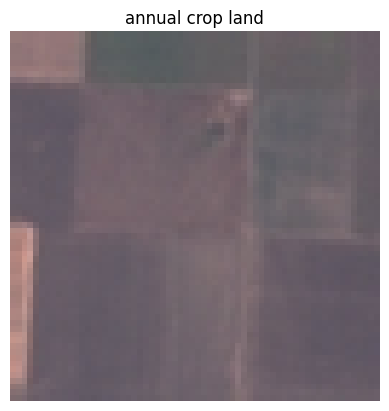

In [5]:
#display single image
image = sample["image"]

plt.imshow(image)
plt.axis("off")
plt.title(class_names[sample["label"]])
plt.show()

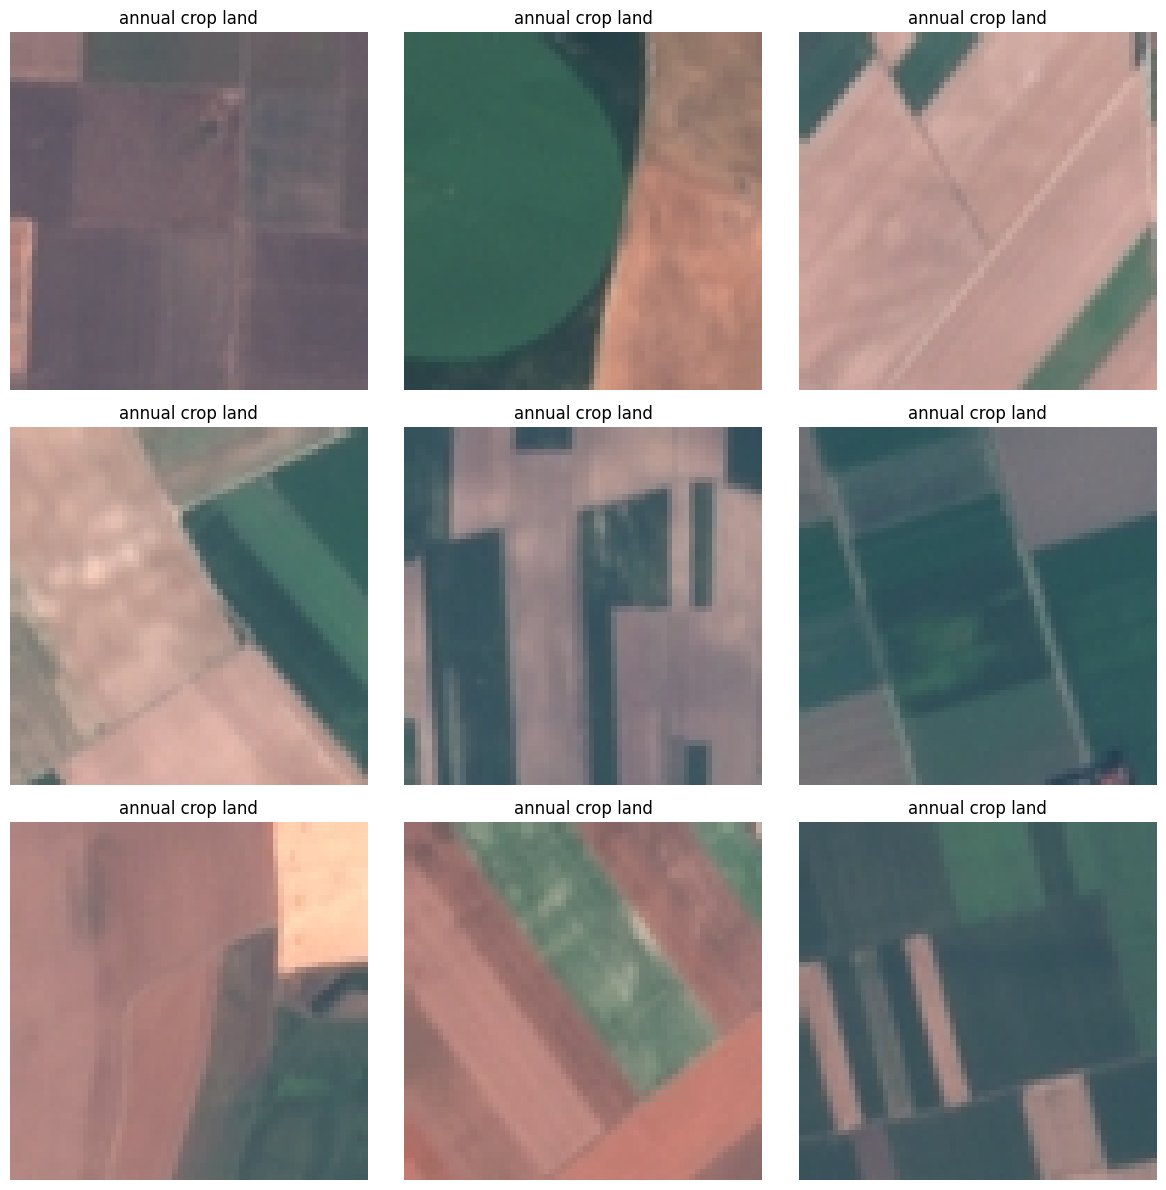

In [6]:
#display multiple images
plt.figure(figsize=(12, 12))

for i in range(9):

    sample = dataset["train"][i]

    plt.subplot(3, 3, i + 1)

    plt.imshow(sample["image"])

    plt.title(class_names[sample["label"]])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
#count image per class
from collections import Counter

labels = dataset["train"]["label"]

label_counts = Counter(labels)

for label, count in sorted(label_counts.items()):
    print(f"{class_names[label]}: {count}")

annual crop land: 2373
forest: 2390
brushland or shrubland: 2381
highway or road: 2012
industrial buildings or commercial buildings: 2012
pasture land: 1626
permanent crop land: 1995
residential buildings or homes or apartments: 2431
river: 1973
lake or sea: 2407


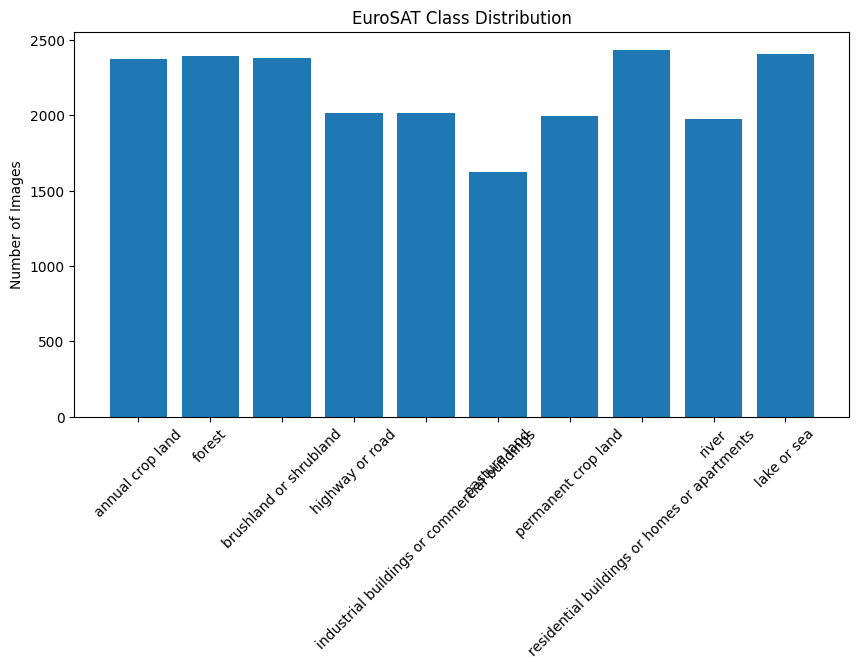

In [8]:
#visualizing class distribution
plt.figure(figsize=(10, 5))

plt.bar(
    class_names,
    [label_counts[i] for i in range(len(class_names))]
)

plt.xticks(rotation=45)

plt.ylabel("Number of Images")

plt.title("EuroSAT Class Distribution")

plt.show()

In [9]:
#checking image size and image mode
print(sample["image"].size)
print(sample["image"].mode)

(64, 64)
RGB


In [10]:
#splitting the dataset
train_test = dataset["train"].train_test_split(
    test_size=0.2,
    seed=42
)

test_valid = train_test["test"].train_test_split(
    test_size=0.5,
    seed=42
)

train_dataset = train_test["train"]
validation_dataset = test_valid["train"]
test_dataset = test_valid["test"]

In [11]:
#reviewing the dataset splits
print("Training Images   :", len(train_dataset))
print("Validation Images :", len(validation_dataset))
print("Test Images       :", len(test_dataset))

Training Images   : 17280
Validation Images : 2160
Test Images       : 2160


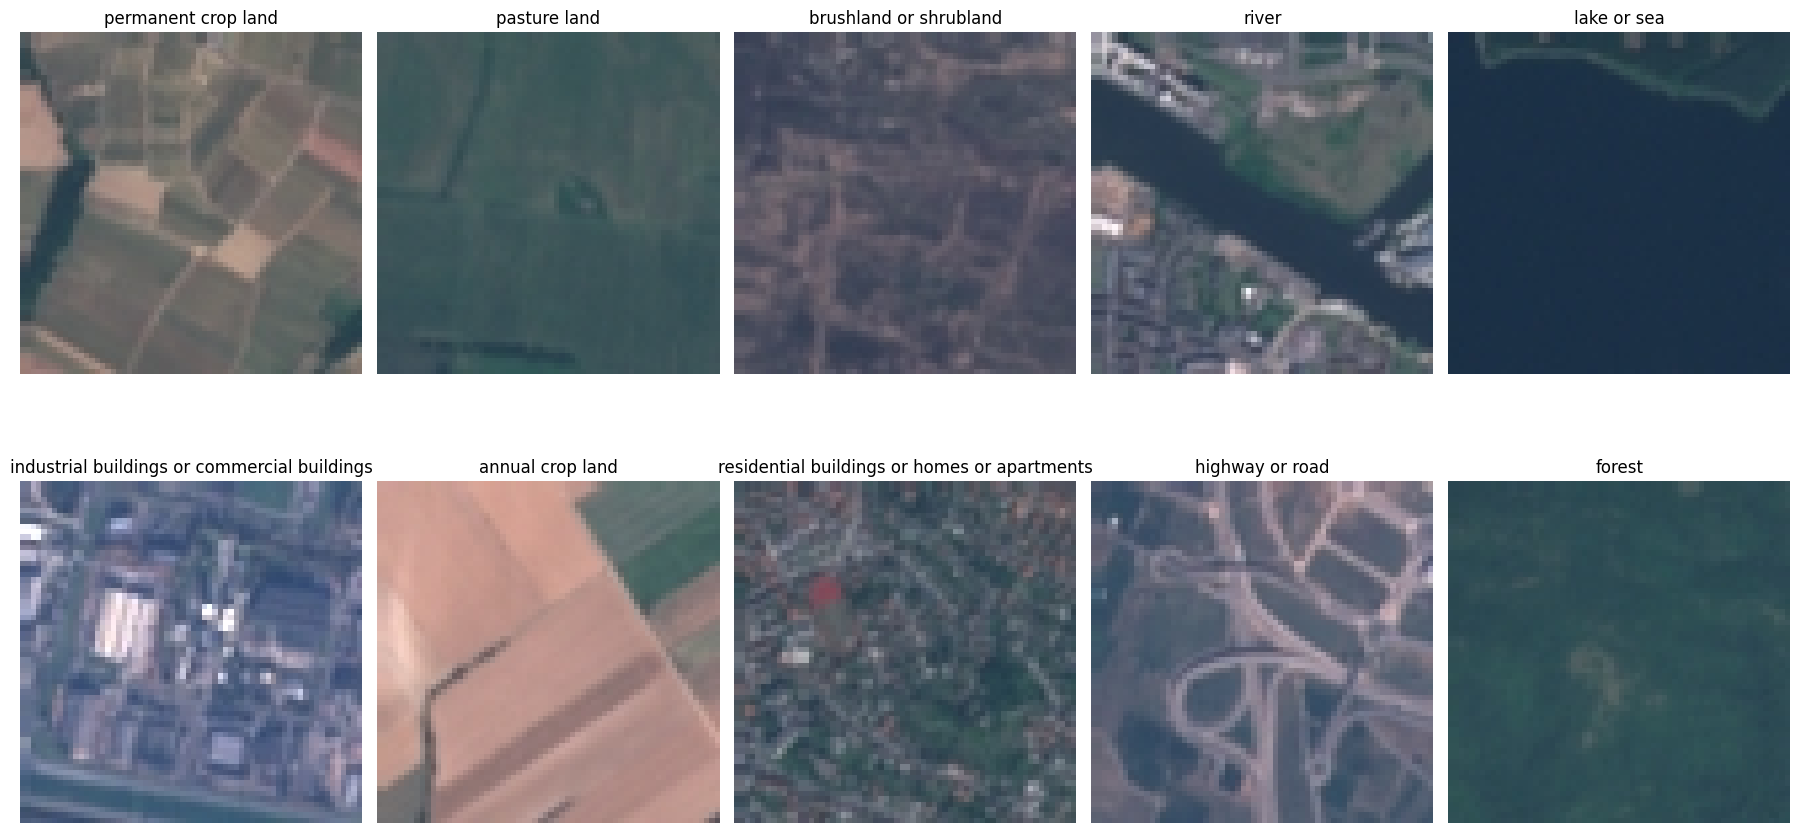

In [12]:
#display sample images from each class
plt.figure(figsize=(18,10))

shown = set()
plot_index = 1

for sample in train_dataset:

    label = sample["label"]

    if label not in shown:

        plt.subplot(2,5,plot_index)

        plt.imshow(sample["image"])

        plt.title(class_names[label])

        plt.axis("off")

        shown.add(label)

        plot_index += 1

    if len(shown) == len(class_names):
        break

plt.tight_layout()

plt.show()

In [13]:
#checking for label encoding
sample = train_dataset[0]

print(sample["label"])

print(class_names[sample["label"]])

6
permanent crop land


In [14]:
#phase 4 image preprocessing
from transformers import AutoImageProcessor
from torchvision.transforms import (
    Compose,
    RandomHorizontalFlip,
    RandomRotation,
    ColorJitter,
    RandomResizedCrop
)

In [15]:
#image processor
checkpoint = "microsoft/swin-tiny-patch4-window7-224"

image_processor = AutoImageProcessor.from_pretrained(checkpoint)
print(image_processor)

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [16]:
#create data augmentation pipeline
train_transforms = Compose([
    RandomResizedCrop(224),
    RandomHorizontalFlip(),
    RandomRotation(15),
    ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    )
])

#validation transform
from torchvision.transforms import Resize

val_transforms = Compose([
    Resize((224,224))
])

In [17]:
#create a preprocessing function
def preprocess_train(batch):

    images = [
        train_transforms(image.convert("RGB"))
        for image in batch["image"]
    ]

    batch["pixel_values"] = image_processor(
        images,
        return_tensors="pt"
    )["pixel_values"]

    return batch

In [18]:
#validation preprocessing
def preprocess_val(batch):

    images = [
        val_transforms(image.convert("RGB"))
        for image in batch["image"]
    ]

    batch["pixel_values"] = image_processor(
        images,
        return_tensors="pt"
    )["pixel_values"]

    return batch

In [19]:
#applying the transformations
train_dataset = train_dataset.with_transform(preprocess_train)

validation_dataset = validation_dataset.with_transform(preprocess_val)

test_dataset = test_dataset.with_transform(preprocess_val)

In [20]:
#inspect one processed image
sample = train_dataset[0]

print(sample["pixel_values"].shape)
#verifying the label and classname
print(sample["label"])
print(class_names[sample["label"]])

torch.Size([3, 224, 224])
6
permanent crop land


In [21]:
#build a data collator
import torch

def collate_fn(batch):

    pixel_values = torch.stack(
        [item["pixel_values"] for item in batch]
    )

    labels = torch.tensor(
        [item["label"] for item in batch]
    )

    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

In [22]:
#testing the collator
batch = collate_fn([
    train_dataset[0],
    train_dataset[1]
])

print(batch["pixel_values"].shape)
print(batch["labels"])

torch.Size([2, 3, 224, 224])
tensor([6, 5])


In [23]:
#verifying the preprocessed final image
print(train_dataset[0].keys())

dict_keys(['image', 'label', 'pixel_values'])


In [24]:
#phase 5 loading the model
from transformers import AutoModelForImageClassification
import torch
checkpoint = "microsoft/swin-tiny-patch4-window7-224"

In [25]:
#create label mapping
label2id = {
    name: str(i)
    for i, name in enumerate(class_names)
}

id2label = {
    str(i): name
    for i, name in enumerate(class_names)
}

In [26]:
#loading the pretrained model
model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(class_names),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [27]:
#inspect the model
print(model)

#verifying number of classes
print(model.config.num_labels)

#verifying label mappings
print(model.config.id2label)

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (attention): SwinAttention(
                (q_proj): Linear(in_features=96, out_features=96, bias=True)
                (k_proj): Linear(in_features=96, out_features=96, bias=True)
                (v_proj): Linear(in_features=96, out_features=96, bias=True)
                (o_proj): Linear(in_features=96, out_features=96, bias=True)
                (relative_position_bias): SwinRelativePositionBias()
              )
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
         

In [28]:
#freezing the backbone for initial training
for param in model.swin.parameters():
  param.requires_grad = False

#verify frozen parameters
  trainable = 0
total = 0

for param in model.parameters():
    total += param.numel()
    if param.requires_grad:
        trainable += param.numel()

print(f"Trainable Parameters: {trainable:,}")
print(f"Total Parameters: {total:,}")

Trainable Parameters: 7,690
Total Parameters: 27,527,044


In [29]:
#verifying the classifier
print(model.classifier)

Linear(in_features=768, out_features=10, bias=True)


In [30]:
#performing a dummy forward pass
sample = train_dataset[0]

pixel_values = sample["pixel_values"].unsqueeze(0)
with torch.no_grad():

    outputs = model(pixel_values=pixel_values)

    print (outputs.logits.shape)

torch.Size([1, 10])


In [31]:
#converting logits into probabilities
probabilities = torch.softmax(outputs.logits, dim=1)

print(probabilities)

#get the predicted class
prediction = torch.argmax(probabilities, dim=1)

print(prediction)

#converting numeric predictions into class name
print(class_names[prediction.item()])

tensor([[0.1197, 0.1532, 0.0974, 0.0687, 0.0653, 0.0948, 0.0960, 0.1055, 0.0805,
         0.1189]])
tensor([1])
forest


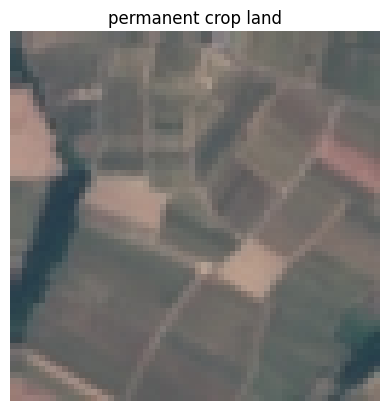

In [32]:
#visualizing the sample
import matplotlib.pyplot as plt

sample = train_dataset[0]

plt.imshow(sample["image"])
plt.axis("off")
plt.title(class_names[sample["label"]])
plt.show()

In [33]:
#phase 6 training and finetuning
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00


In [34]:
import evaluate
import numpy as np
from transformers import (
    Trainer,
    TrainingArguments
)

#loading accuracy metric
accuracy = evaluate.load("accuracy")


In [35]:
#defining evaluation function
def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

In [36]:
#creating output directory
output_dir = "./swin-eurosat"

#configuring Training Arguments
training_args = TrainingArguments(

    output_dir=output_dir,

    per_device_train_batch_size=32,

    per_device_eval_batch_size=32,

    num_train_epochs=5,

    learning_rate=5e-4,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    remove_unused_columns=False,

    report_to="none"
)

In [37]:
import transformers

print(transformers.__version__)

import inspect
print(inspect.signature(TrainingArguments))

5.12.1
(output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_c

In [38]:
#creating the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    processing_class=image_processor
)

In [39]:
#start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.735528,0.392120,0.898148
2,0.420266,0.329372,0.908796
3,0.381643,0.301695,0.916204
4,0.367072,0.277963,0.921296
5,0.355722,0.278221,0.920833


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['swin.encoder.layers.0.blocks.0.attention.q_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.q_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.k_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.k_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.v_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.v_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.o_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.o_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.relative_position_bias.relative_position_bias_table', 'swin.encoder.layers.0.blocks.0.mlp.fc1.weight', 'swin.encoder.layers.0.blocks.0.mlp.fc1.bias', 'swin.encoder.layers.0.blocks.0.mlp.fc2.weight', 'swin.encoder.layers.0.blocks.0.mlp.fc2.bias', 'swin.encoder.layers.0.blocks.1.attention.q_proj.weight', 'swin.encoder.layers.0.blocks.1.attention.q_proj.bias', 'swin.encoder.layers.0.blocks.1.attention.k_proj.weight', 'swin.encode

TrainOutput(global_step=2700, training_loss=0.4520460001627604, metrics={'train_runtime': 892.6417, 'train_samples_per_second': 96.791, 'train_steps_per_second': 3.025, 'total_flos': 2.1480375117938688e+18, 'train_loss': 0.4520460001627604, 'epoch': 5.0})

In [40]:
#model evaluation
trainer.evaluate(test_dataset)

Training Loss,Validation Loss,Epoch,Accuracy
0.355722,0.277545,5,0.917593


{'eval_loss': 0.2775448262691498, 'eval_accuracy': 0.9175925925925926}

In [41]:
#save the stage1 model
trainer.save_model("Stage1_model")
#save the image processor
image_processor.save_pretrained("Stage1_model")
#inspect training logs
trainer.state.log_history

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[{'loss': 0.7355281123408565,
  'grad_norm': 1.2348816394805908,
  'learning_rate': 0.0004001851851851852,
  'epoch': 1.0,
  'step': 540},
 {'eval_loss': 0.39212048053741455,
  'eval_accuracy': 0.8981481481481481,
  'eval_runtime': 17.1841,
  'eval_samples_per_second': 125.698,
  'eval_steps_per_second': 3.957,
  'epoch': 1.0,
  'step': 540},
 {'loss': 0.42026553683810763,
  'grad_norm': 0.6621121168136597,
  'learning_rate': 0.0003001851851851852,
  'epoch': 2.0,
  'step': 1080},
 {'eval_loss': 0.3293721079826355,
  'eval_accuracy': 0.9087962962962963,
  'eval_runtime': 12.0551,
  'eval_samples_per_second': 179.177,
  'eval_steps_per_second': 5.641,
  'epoch': 2.0,
  'step': 1080},
 {'loss': 0.381642829047309,
  'grad_norm': 1.0189249515533447,
  'learning_rate': 0.0002001851851851852,
  'epoch': 3.0,
  'step': 1620},
 {'eval_loss': 0.3016953766345978,
  'eval_accuracy': 0.9162037037037037,
  'eval_runtime': 11.9712,
  'eval_samples_per_second': 180.433,
  'eval_steps_per_second': 5.6

In [44]:
#inspect the model structure
print(model.swin)

#freeze everything again
for param in model.swin.parameters():
  param.requires_grad = False
#unfreeze the last swine stage
for param in model.swin.encoder.layers[3].parameters():
  param.requires_grad = True

SwinModel(
  (embeddings): SwinEmbeddings(
    (patch_embeddings): SwinPatchEmbeddings(
      (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    )
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): SwinEncoder(
    (layers): ModuleList(
      (0): SwinStage(
        (blocks): ModuleList(
          (0): SwinLayer(
            (attention): SwinAttention(
              (q_proj): Linear(in_features=96, out_features=96, bias=True)
              (k_proj): Linear(in_features=96, out_features=96, bias=True)
              (v_proj): Linear(in_features=96, out_features=96, bias=True)
              (o_proj): Linear(in_features=96, out_features=96, bias=True)
              (relative_position_bias): SwinRelativePositionBias()
            )
            (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (layernorm_after): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
   

In [45]:
#keep the classifier trainable
for param in model.classifier.parameters():
  param.requires_grad = True
#verify trainable parameters
trainable = 0
total = 0

for param in model.parameters():
    total += param.numel()

    if param.requires_grad:
        trainable += param.numel()

print(f"Trainable Parameters: {trainable:,}")
print(f"Total Parameters: {total:,}")
print(f"Percentage: {100 * trainable / total:.2f}%")

Trainable Parameters: 14,191,546
Total Parameters: 27,527,044
Percentage: 51.55%


In [46]:
#create new training arguments
from transformers import TrainingArguments

fine_tune_args = TrainingArguments(

    output_dir="./swin_finetuned",

    per_device_train_batch_size=32,

    per_device_eval_batch_size=32,

    num_train_epochs=5,

    learning_rate=1e-5,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    remove_unused_columns=False,

    report_to="none"
)

In [47]:
#creating a new trainer
from transformers import Trainer

fine_tune_trainer = Trainer(

    model=model,

    args=fine_tune_args,

    train_dataset=train_dataset,

    eval_dataset=validation_dataset,

    data_collator=collate_fn,

    compute_metrics=compute_metrics,

    processing_class=image_processor
)

In [49]:
#training the last stage
fine_tune_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.260420,0.158702,0.946759
2,0.242276,0.148343,0.952315
3,0.231593,0.148329,0.947222
4,0.228892,0.141698,0.954630
5,0.221735,0.141929,0.953241


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['swin.encoder.layers.0.blocks.0.attention.q_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.q_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.k_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.k_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.v_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.v_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.o_proj.weight', 'swin.encoder.layers.0.blocks.0.attention.o_proj.bias', 'swin.encoder.layers.0.blocks.0.attention.relative_position_bias.relative_position_bias_table', 'swin.encoder.layers.0.blocks.0.mlp.fc1.weight', 'swin.encoder.layers.0.blocks.0.mlp.fc1.bias', 'swin.encoder.layers.0.blocks.0.mlp.fc2.weight', 'swin.encoder.layers.0.blocks.0.mlp.fc2.bias', 'swin.encoder.layers.0.blocks.1.attention.q_proj.weight', 'swin.encoder.layers.0.blocks.1.attention.q_proj.bias', 'swin.encoder.layers.0.blocks.1.attention.k_proj.weight', 'swin.encode

TrainOutput(global_step=2700, training_loss=0.23698311699761285, metrics={'train_runtime': 1061.5439, 'train_samples_per_second': 81.391, 'train_steps_per_second': 2.543, 'total_flos': 2.414553277146071e+18, 'train_loss': 0.23698311699761285, 'epoch': 5.0})

In [50]:
#evaluating the model
results = fine_tune_trainer.evaluate(test_dataset)

print(results)

#save the fine-tuned model
fine_tune_trainer.save_model("swin_eurosat_final")

image_processor.save_pretrained("swin_eurosat_final")

Training Loss,Validation Loss,Epoch,Accuracy
0.221735,0.146046,5,0.948611


{'eval_loss': 0.14604587852954865, 'eval_accuracy': 0.9486111111111111}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['swin_eurosat_final/preprocessor_config.json']

In [66]:
#model evaluation and performance analysis
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [68]:
#put the model in evaluation mode
model.eval()

#initialize lists
predictions = []
true_labels = []

#make predictions on test set
for sample in test_dataset:

    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

    label = sample["label"]

    with torch.no_grad():

        outputs = model(pixel_values=pixel_values)

    prediction = outputs.logits.argmax(dim=1).item()

    predictions.append(prediction)

    true_labels.append(label)

KeyboardInterrupt: 

In [69]:
from tqdm.auto import tqdm

predictions = []
true_labels = []

model.eval()

for sample in tqdm(test_dataset):

    pixel_values = sample["pixel_values"].unsqueeze(0)

    label = sample["label"]

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    prediction = outputs.logits.argmax(dim=1).item()

    predictions.append(prediction)
    true_labels.append(label)

  0%|          | 0/2160 [00:00<?, ?it/s]

In [64]:
device = next(model.parameters()).device

model.eval()

predictions = []
true_labels = []

for sample in test_dataset:

    inputs = sample["pixel_values"].unsqueeze(0).to(device)

    label = sample["label"]

    with torch.no_grad():
        logits = model(pixel_values=inputs).logits

    pred = logits.argmax(dim=1).cpu().item()

    predictions.append(pred)
    true_labels.append(label)

KeyboardInterrupt: 

In [70]:
#calculate accuracy
accuracy = accuracy_score(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")

#calculate precision
precision = precision_score(
    true_labels,
    predictions,
    average="weighted"
)

print(f"Precision: {precision:.4f}")

#calculate recall
recall = recall_score(
    true_labels,
    predictions,
    average="weighted"
)

print(f"Recall: {recall:.4f}")

#calculate f1 score
f1 = f1_score(
    true_labels,
    predictions,
    average="weighted"
)

print(f"F1 Score: {f1:.4f}")



Accuracy: 0.9486
Precision: 0.9490
Recall: 0.9486
F1 Score: 0.9486


In [71]:
#printing the classification report
print(
    classification_report(
        true_labels,
        predictions,
        target_names=class_names
    )
)

                                              precision    recall  f1-score   support

                            annual crop land       0.95      0.95      0.95       234
                                      forest       0.98      0.98      0.98       240
                      brushland or shrubland       0.95      0.91      0.93       222
                             highway or road       0.93      0.90      0.92       186
industrial buildings or commercial buildings       0.95      1.00      0.97       225
                                pasture land       0.90      0.94      0.92       157
                         permanent crop land       0.90      0.94      0.92       203
residential buildings or homes or apartments       0.99      0.96      0.97       255
                                       river       0.93      0.90      0.92       189
                                 lake or sea       0.97      0.98      0.98       249

                                    accuracy        

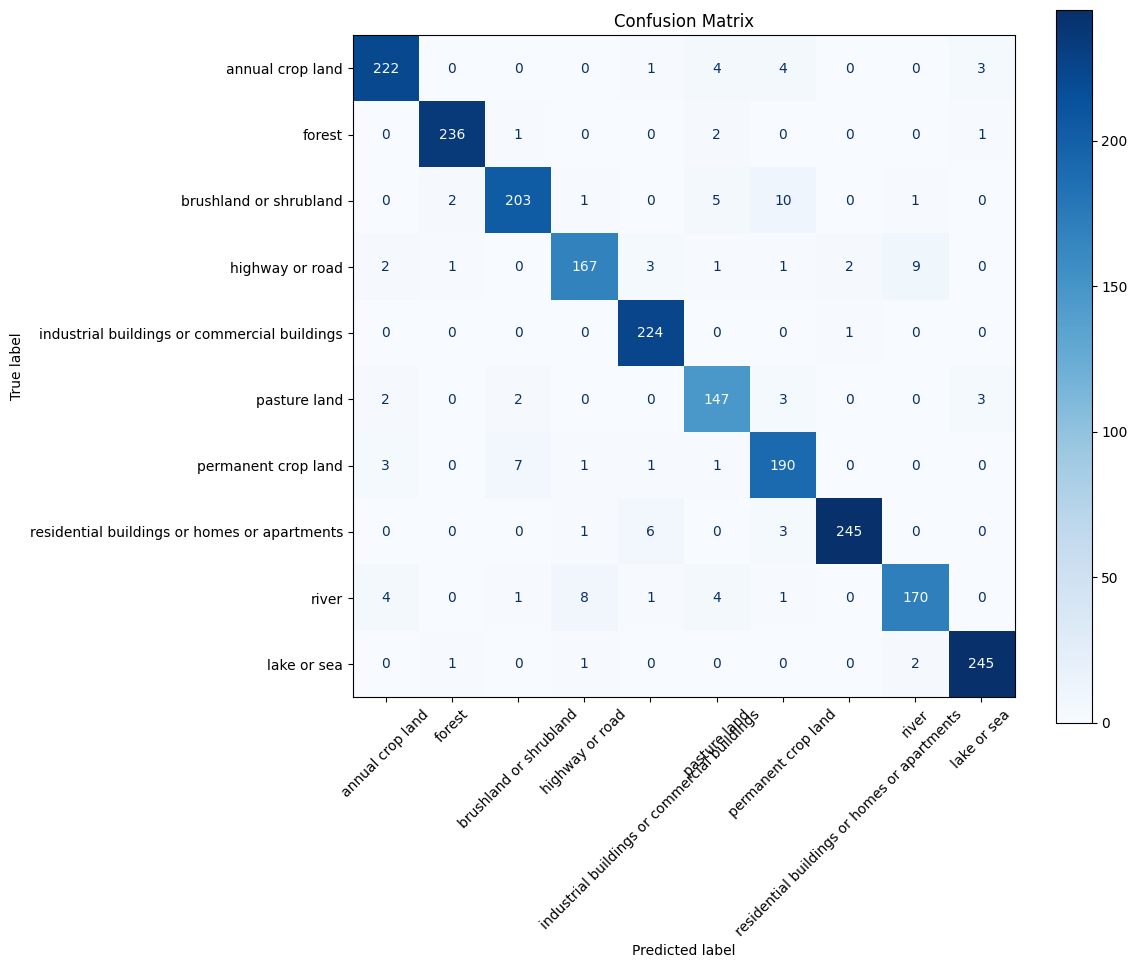

In [72]:
#confusion matrix
cm = confusion_matrix(
    true_labels,
    predictions
)
#plot the matrix
fig, ax = plt.subplots(figsize=(12,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

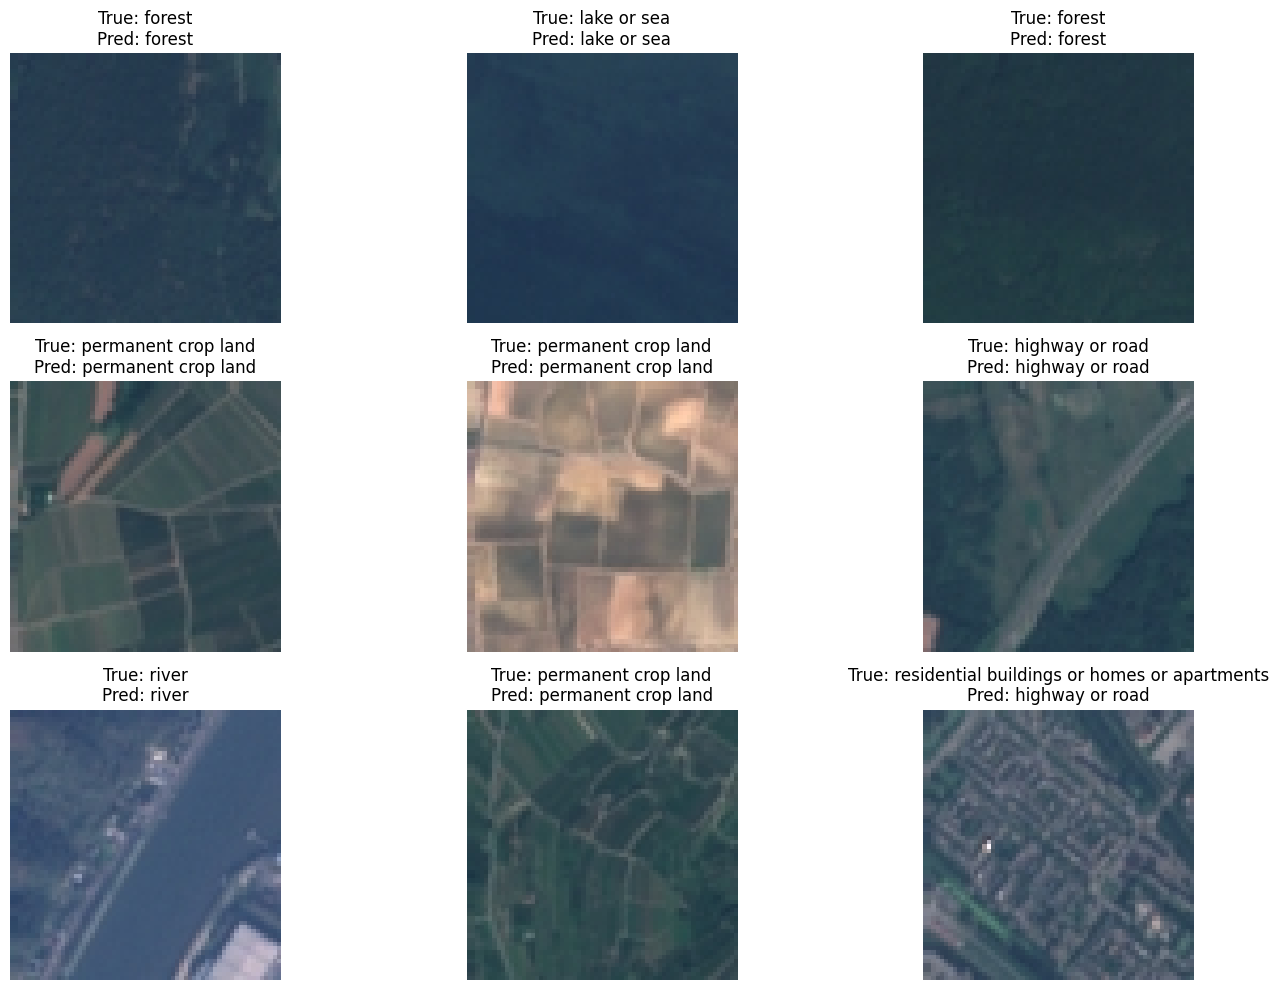

In [73]:
#plot sample predictions
import random

plt.figure(figsize=(15,10))

for i in range(9):

    index = random.randint(0, len(test_dataset)-1)

    sample = test_dataset[index]

    image = sample["image"]

    pixel_values = sample["pixel_values"].unsqueeze(0)

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)

    pred = outputs.logits.argmax(dim=1).item()

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(
        f"True: {class_names[sample['label']]}\nPred: {class_names[pred]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [74]:
#save the confusion matrix
fig.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

#save the classification report
report = classification_report(
    true_labels,
    predictions,
    target_names=class_names
)

with open("classification_report.txt", "w") as f:
    f.write(report)

In [75]:
#getting input from the user
import torch
from PIL import Image
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification
)
from google.colab import files
import matplotlib.pyplot as plt

In [76]:
#load the fine tuned model
model_path = "swin_eurosat_final"

image_processor = AutoImageProcessor.from_pretrained(model_path)

model = AutoModelForImageClassification.from_pretrained(model_path)

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

In [79]:
#set evaluation mode
model.eval()

#upload the image
uploaded = files.upload()

#get the uploaded file name
image_path = next(iter(uploaded))

#load the image
image = Image.open(image_path).convert("RGB")


Saving forest image.jpg to forest image (2).jpg


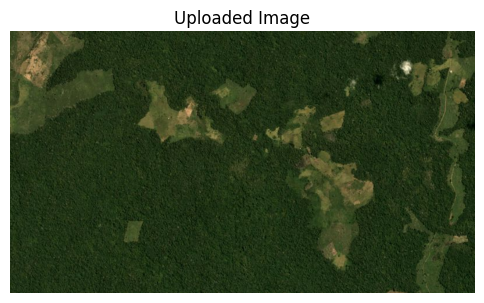

In [80]:
#display the uploaded image
plt.figure(figsize=(6,6))

plt.imshow(image)

plt.axis("off")

plt.title("Uploaded Image")

plt.show()

In [81]:
#preprocess the image
inputs = image_processor(
    image,
    return_tensors="pt"
)

#run inference
with torch.no_grad():

    outputs = model(**inputs)

In [85]:
#convert logits to probabilities
probabilities = torch.softmax(
    outputs.logits,
    dim=1
)

#get the predicted class
predicted_class = probabilities.argmax(dim=1).item()

predicted_label = model.config.id2label[predicted_class]

confidence = probabilities[0][predicted_class].item()

#display the predictions
print(f"Predicted Class : {predicted_label}")

print(f"Confidence      : {confidence*100:.2f}%")

Predicted Class : forest
Confidence      : 94.91%


In [86]:
#top 5 predictions
top5 = torch.topk(probabilities, k=5)
print("Top 5 Predictions\n")

for probability, index in zip(top5.values[0], top5.indices[0]):

    label = model.config.id2label[int(index)]

    print(f"{label:25} {probability.item()*100:.2f}%")

Top 5 Predictions

forest                    94.91%
brushland or shrubland    1.40%
annual crop land          1.40%
permanent crop land       0.84%
pasture land              0.76%


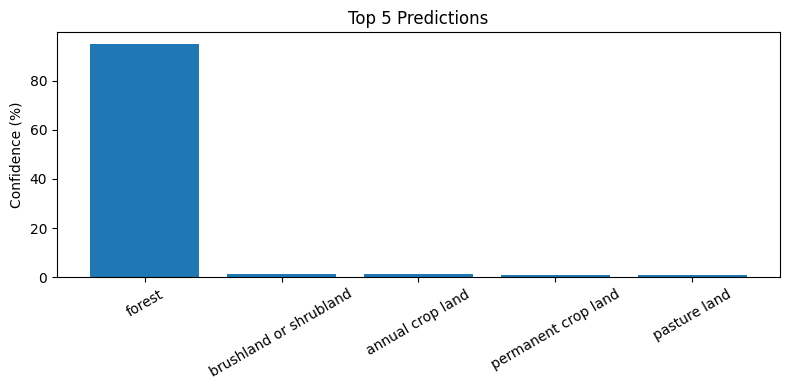

In [87]:
#create a probability bar chart
top5_labels = [
    model.config.id2label[int(i)]
    for i in top5.indices[0]
]

top5_scores = [
    p.item() * 100
    for p in top5.values[0]
]

plt.figure(figsize=(8,4))

plt.bar(top5_labels, top5_scores)

plt.ylabel("Confidence (%)")

plt.title("Top 5 Predictions")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [88]:
#wrapping in the reusable function
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = image_processor(image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)

    predicted_class = probabilities.argmax(dim=1).item()

    label = model.config.id2label[int(predicted_class)]

    confidence = probabilities[0][predicted_class].item()

    return label, confidence